## 10. Diferenças finitas para EDOs parabólicas

Agora podemos expressar a solução propagada no tempo $t_{n+1}$ para cada um dos $N_x-2$ pontos $x_i$ no interior da malha em termos de valores no tempo $t_n$

$$u_i^{n+1}=\lambda u_{i-1}^n+(1-2 \lambda) u_i^n+\lambda u_{i+1}^n, \quad i=2,3, \ldots, N_x-1$$

em que 

$$\lambda=\frac{D h_t}{h_x^2}$$

Para as extremidades, a solução permanece constante e igual à condição inicial (condição de *Dirichlet*), ou seja, 

$$
u_1^{n+1}=u_1^n=u_0^0, \quad u_{N_x}^{n+1}=u_{N_x}^n=u_L^0
$$


Na forma matricial podemas escrever 
$$
\mathbf{u}^{n+1}=\mathbf{B} \cdot \mathbf{u}^n, \quad n=0,1,2, \ldots
$$

A matriz de propagação $\mathbf{B}$ é triagonal e o vetor $\mathbf{u}^n$ fornece a solução em todos os pontos da malha para o passo de tempo $t_n$

$$
\mathbf{B}=\left[\begin{array}{ccccc}
1 & 0 & & & 0 \\
\lambda & 1-2 \lambda & \lambda & & \\
& \ddots & \ddots & \ddots & \\
& & \lambda & 1-2 \lambda & \lambda \\
0 & & & 0 & 1
\end{array}\right], \quad \mathbf{u}^n=\left[\begin{array}{c}
u_1^n \\
u_2^n \\
\vdots \\
u_{N_n-1}^n \\
u_{N_x}^n
\end{array}\right]$$

Cada componente da solução propagada $\mathbf{u}^{n+1}$ resulta do produto da matriz $\mathbf{B}$ com o vetor  $\mathbf{u}^{n}$. 

**Exemplo 1:** (Beu, 2014) Vamos resolver a equação da difusão 1D

$$
\frac{\partial u}{\partial t}=D \frac{\partial^2 u}{\partial x^2}, \quad x \in[0, L], \quad t>0
$$

com coeficiente de difusão constante, sujeita às condições de contorno de Dirichlet

$$
u(0, t)=u(L, t)=0, \quad t>0
$$

e com a condição inicial dada por

$$
u(x, 0)=\sin (\pi x / L), \quad x \in[0, L] .
$$


A solução exata para esse problema é dada por

$$u(x,t)=e^{\frac{-\pi^2Dt}{L^2}} \text{sen}\left(\frac{\pi x}{L} \right) .$$

Vamos usar nesse exemplo $L=1$, $D=0.1$, $h_t = 0.00125 s$ e $h_x=0.05$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
L = 1                        # comprimento da barra
nx = 20                      # número de subintervalos em x
D = 0.1                      # difusividade térmica 
ht=0.0125                    # tamanho do passo de tempo
hx = L/nx                    # espaçamento entre os nós
lamb =  D*ht/hx**2           # lambda

In [3]:
x = np.linspace(0,L,nx+1)     # criação da malha
u = np.sin(np.pi*x)           # criando o vetor u0=0

In [4]:
# criação da matriz B
B = np.eye(len(x))            # criando uma matriz identidade
for i in range(1,len(B)-1):   # alterando as diagonais
    B[i,i-1]=lamb               
    B[i,i]=1-2*lamb
    B[i,i+1]=lamb

In [5]:
# propagando e armazenando as soluções
sol = np.array([u])
for n in range(480):
    u[0]=u[-1]=0
    u = B@u 
    sol = np.vstack((sol,[u]))

In [6]:
# escrevendo a solução exata
sol_ex = lambda x,t: np.exp(-np.pi**2*D*t/L**2)*np.sin(np.pi*x/L) 

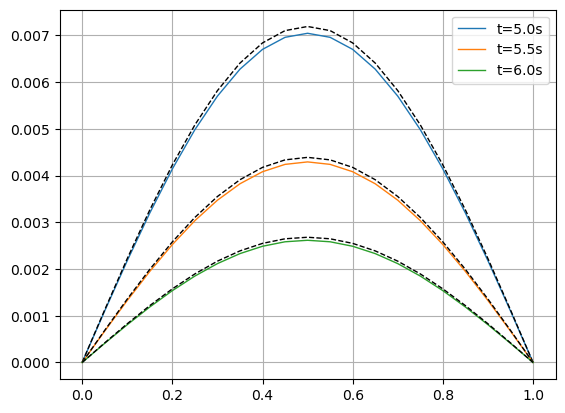

In [7]:
# plotando para alguns valores de t
fig, ax = plt.subplots()
ns = [400,440,480]
for n in ns:
    label='t='+str(n*ht)+'s'
    plt.plot(x,sol[n],label=label, lw=1)
    s_ex = sol_ex(x,n*ht)
    plt.plot(x, s_ex, "k--", lw=1)
ax.legend()
ax.grid()
plt.show()

Segundo o critério de von Neumann, o método irá convergir para valores de $\lambda$ tais que $0<\lambda<1/2$.

**Como experimento, tente mudar o passo de tempo para $h_t=0.013$ no exemplo anterior e veja o resultado.**

### Solução explícita da condução de calor unidimensional 

(Fonte: [Chapra, 2016](https://integrada.minhabiblioteca.com.br/reader/books/9788580555691/pageid/783))

Vamos estudar o balanço de calor para um elemento infinitesimal na barra (ou haste) isolada, longa e fina, e as variações das temperaturas ao longo de um um periodo de tempo. Para isso, vamos considerar a equaçao da condução de calor:

$$
k \frac{\partial^2 T}{\partial x^2}=\frac{\partial T}{\partial t}
$$

em que $k$ é o *coeficiente de difusividade térmica* do material.


Substituindo as aproximações para a segunda derivada no espaço (o índice $i$ refere-se ao ponto da malha unidimensional e o índice $l$ sobreescrito é usado para denotar o tempo)

$$
\frac{\partial^2 T}{\partial x^2}=\frac{T_{i+1}^l-2 T_i^l+T_{i-1}^l}{\Delta x^2}
$$

e para a primeira derivada no tempo

$$
\frac{\partial T}{\partial t}=\frac{T_i^{l+1}-T_i^l}{\Delta t}
$$

na equação do calor, obtemos

$$
k \frac{T_{i+1}^l-2 T_i^l+T_{i-1}^l}{(\Delta x)^2}=\frac{T_i^{l+1}-T_i^l}{\Delta t}
$$

que pode ser reescrita como
$$T_i^{l+1}=T_i^l+\lambda\left(T_{i+1}^l-2 T_i^l+T_{i-1}^l\right)$$

onde $\lambda=k \frac{\Delta t}{(\Delta x)^2}$. O método explícito é convergente e estável par $\lambda \leq 1/2$.

As vezes $k$ é dado em função do *coeficiente de condutividade térmica* $k'$ $\left(\frac{cal}{s\cdot cm\cdot °C} \right)$, da densidade do material $\rho$ $(g/cm^3)$ e da capacidade calorífica do material $C$ $\left(\frac{cal}{g\cdot °C} \right)$ pela relação $k'=k \rho C$ ou 

$$k =  \frac{k'}{\rho C}$$

**Exemplo 1:** ([Fonte](https://integrada.minhabiblioteca.com.br/reader/books/9788580555691/pageid/784))
Determinar a distribuição de temperatura de uma barra longa e fina, com um comprimento de $10 cm$ e com os seguintes valores: (coeficiente de condutividade térmica) $k' = 0,49$ cal/(s · cm · $^\circ$C);$\Delta x = 2$ cm e $\Delta t = 0,1$ s.

Em $t = 0$, a temperatura da barra é zero e as condições de contorno são fixas em todos os tempos em $T(0) = 100 ^\circ C$ e $T(10) = 50 ^\circ C$. Observe que a barra é de alumínio com $C = 0,2174$ cal/(g·$^\circ$C) e $ρ = 2,7 g/cm^3$. 

Portanto, $k = 0,49/(2,7 · 0,2174) = 0,835 cm2/s$ e	$\lambda= 0,835(0,1)/ 2^2 = 0,020875$.


In [8]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [4,2]

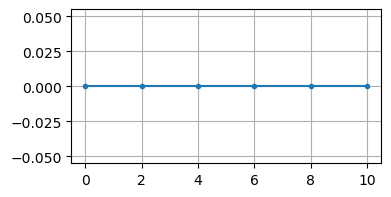

In [9]:
L = 10 #cm (comprimento) 
dx = 2.0     # cm
# Coordenada dos pontos
xi = np.arange(0, L+dx, dx)
T = [np.zeros(len(xi))]

plt.plot(xi, T[0],'.-')
plt.grid()
plt.show()

In [10]:
dt = 0.1     # seg
kl = 0.49    # cal/(s cm ºC)
C = 0.2174   # cal/(g ºC)
p = 2.7      # g/cm³

k = kl/(p*C)
lamb = k*(dt/dx**2) 
print("Lambda=", lamb)

Lambda= 0.020869535588946813


[100.   0.   0.   0.   0.  50.]
[0. 0. 0. 0.]
[2.08695356 0.         0.         1.04347678]
[4.08679961 0.04355375 0.02177688 2.04339981]
[6.0040829  0.12747994 0.06442168 3.00204145]


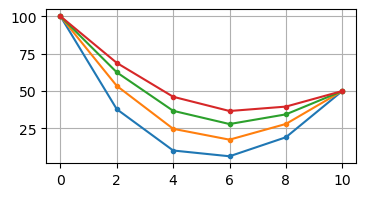

In [11]:
# Temperaturas em cada instante
# (lista para armazenar os dados)# Estado inicial
T0 = np.full(len(xi), 0.0)

# Condições de contorno
T0[0] = 100.
T0[-1] = 50.
print(T0)
T = [T0]

# Calculando
for t in range(121):
    Tb = T[-1].copy() 
    Tf = T[-1].copy()
    Tf[1:-1] = Tb[1:-1]+lamb*(Tb[2:]-2*Tb[1:-1]+Tb[0:-2])
    T.append(Tf)

print(T[0][1:-1])
print(T[1][1:-1])   
print(T[2][1:-1])   
print(T[3][1:-1])
plt.figure(figsize=(4,2))
plt.plot(xi, T[30],'.-')
plt.plot(xi, T[60],'.-')
plt.plot(xi, T[90],'.-')
plt.plot(xi, T[120],'.-')

plt.grid()

### Uma solução implícita simples da equação de condução de calor
Nos métodos implícitos, a derivada espacial é aproximada em um nível de tempo avançado, $l + 1$. Por exemplo, a segunda derivada seria aproximada por 

$$\frac{\partial^2 T}{\partial x^2} \cong \frac{T_{i+1}^{l+1}-2 T_i^{l+1}+T_{i-1}^{l+1}}{(\Delta x)^2}$$

Substituindo na equação do calor, obtem-se

$$
k \frac{T_{i+1}^{l+1}-2 T_i^{l+1}+T_{i-1}^{l+1}}{(\Delta x)^2}=\frac{T_i^{l+1}-T_i^l}{\Delta t}
$$

que pode ser expressa como

$$
-\lambda T_{i-1}^{l+1}+(1+2 \lambda) T_i^{l+1}-\lambda T_{i+1}^{l+1}=T_i^l
$$

Essa equação se aplica a todos, exceto o primeiro e o último nós interiores, nos quais precisa ser modificada para refletir as condições de contorno. Assim, em resumo, tem-se:


**Para o primeiro nó interior:**

$$
(1+2 \lambda) T_1^{l+1}-\lambda T_2^{l+1}=T_1^l+\lambda T_0^{l+1}
$$

**Todos exceto o primeiro e o último:**

$$
-\lambda T_{i-1}^{l+1}+(1+2 \lambda) T_i^{l+1}-\lambda T_{i+1}^{l+1}=T_i^l
$$

**Para o último nó interior:**

$$
-\lambda T_{m-1}^{l+1}+(1+2 \lambda) T_m^{l+1}=T_m^l+\lambda T_{m+1}^{l+1}
$$

**Exemplo 2:** ([Fonte](https://integrada.minhabiblioteca.com.br/reader/books/9788580555691/pageid/787)) Use a aproximação implícita simples por diferenças finitas para resolver o mesmo problema que no Exemplo 1.

Aplicando das equações de diferenças obtemos o seguinte sistema:
$$
\left[\begin{array}{cccc}
1,04175 & -0,020875 & & \\
-0,020875 & 1,04175 & -0,020875 & \\
& -0,020875 & 1,04175 & -0,020875 \\
& & -0,020875 & 1,04175
\end{array}\right]\left\{\begin{array}{l}
T_1^1 \\
T_2^1 \\
T_3^1 \\
T_4^1
\end{array}\right\}=\left\{\begin{array}{c}
2,0875 \\
0 \\
0 \\
1,04375
\end{array}\right\}
$$

que deve ser resolvido para determinar as temperatiuras em $t=0,1$s.

Para determinar as temperaturas em $t = 0,2$, o vetor à direita deve ser modificado para levar em conta os resultados do primeiro passo.

In [12]:
M = np.zeros((6,6))
for i in range(1,len(M)-1):
    M[i,i-1]=-lamb
    M[i,i]=1+2*lamb
    M[i,i+1]=-lamb
A = M[1:-1,1:-1]
print(np.round(A,4))

[[ 1.0417 -0.0209  0.      0.    ]
 [-0.0209  1.0417 -0.0209  0.    ]
 [ 0.     -0.0209  1.0417 -0.0209]
 [ 0.      0.     -0.0209  1.0417]]


In [13]:
# Temperaturas em cada instante
T0 = np.full(len(xi), 0.0)

# Condições de contorno
T0[0] = 100.
T0[-1] = 50.
T = [T0]

B0 = np.zeros(4)
B0[0] = T0[0]*lamb
B0[-1] = T0[-1]*lamb

print(B0)

[2.08695356 0.         0.         1.04347678]


In [14]:
np.linalg.solve(A,B0)

array([2.00414889, 0.04056829, 0.02088788, 1.00208654])

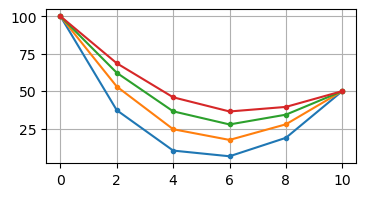

In [15]:
for i in range(121):
    B = B0 + T[-1][1:-1]
    s = np.linalg.solve(A,B)
    Tf = T[-1].copy()
    Tf[1:-1] = s
    T.append(Tf)
    #print(s)

plt.plot(xi, T[30],'.-')
plt.plot(xi, T[60],'.-')
plt.plot(xi, T[90],'.-')
plt.plot(xi, T[120],'.-')

plt.grid()

**Equação do calor 2D transiente**

$$\frac{\partial u}{\partial t}-\alpha \nabla u = 0 $$

em 2d fica

$$\frac{\partial u}{\partial t}-\alpha \left( \frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} \right)= 0 $$

Na função $u(x,y,t) = u^k_{i,j}$ os índices $i$ , $j$ , e $k$ indicam os passos em $x$ , $y$ e em $t$ respectivamente.  


Podemos escrever a equação de calor acima usando o método de diferenças finitas como este



$$ \frac{u^{k+1}_{i,j} -u^{k}_{i,j}}{h_t} 
-\alpha \left(\frac{u^k_{i+1,j} - 2u^k_{i,j} + u^k_{i-1,j}}{h_x^2} 
+ \frac{u^k_{i,j+1} - 2u^k_{i,j} + u^k_{i,j-1}}{h_y^2} \right) = 0$$

Se organizarmos a equação acima tomando $h_x=h_y=h$, obtemos esta equação final

$$ u^{k+1}_{i,j}= \gamma \left(u^k_{i+1,j} + u^k_{i-1,j} - 4u^k_{i,j} + u^k_{i,j+1}+u^k_{i,j-1} \right) + u^k_{i,j}$$

onde 

$$\gamma = \alpha \frac{h_t}{h^2}$$

Usamos o método explícito numericamente estável para

$$h_t< \frac{h^2}{4\alpha}$$

**Exemplo:**

Suponhamos uma placa quadrada fina com lado de 50 unidades de comprimento. A temperatura em todos os lugares dentro da placa é originalmente de 0 grau (em $t = 0$). Vamos considerar $h = 1$ e $\alpha = 2.0$. Agora podemos usar o código Python para resolver este problema numericamente para ver a temperatura em todos os lugares (indicada por $i$ e $j$ ) e ao longo do tempo (indicada por $k$). 

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.animation import FuncAnimation

In [17]:
xmax = 20
ymax = 40
kmax = 200

alpha = 2
h = 1
ht = (h ** 2)/(4 * alpha)
gamma = (alpha * ht) / (h ** 2)

# Cria o array para u(t,x,y)
u = np.empty((kmax, xmax, ymax))

# Condição inicial
u.fill(0)

# Condições de contorno
u[:,-1:,:] = 100.0  #top
u[:,:,:1] = 0             #left
u[:,:1,1:] = 0            #bottom
u[:,:,-1:] = 0      #right


Definimos as condições iniciais e de contorno, vamos escrever a função de cálculo com base no método de diferenças finitas que derivamos acima.

In [18]:
def calcula(u):
    for k in range(0, kmax-1, 1):
        for i in range(1, xmax -1, h):
            for j in range(1, ymax -1, h):
                u[k+1,i,j] = gamma*(u[k,i+1,j]+u[k,i-1,j]+u[k,i,j+1]+u[k,i,j-1]- 4*u[k,i,j]) + u[k,i,j]

    return u

In [19]:
u = calcula(u)

Vamos preparar a função plot para que possamos visualizar a solução (para cada k ) como um mapa de calor. Usamos a biblioteca Matplotlib , é fácil de usar.

In [20]:
def plotheatmap(u_k, k):
    plt.clf()  # clear figure
    plt.title(f"Temperatura em k = {k*ht:.3f} unidades de tempo")
    plt.xlabel("x")
    plt.ylabel("y")

    # This is to plot u_k (u at time-step k)
    plt.pcolormesh(u_k, cmap=plt.cm.jet, vmin=0, vmax=100)
    #plt.contourf(X,Y,u_k, cmap=plt.cm.jet)
    plt.colorbar()
    plt.show()
    #return plt

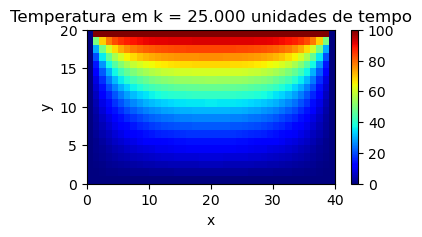

In [21]:
plotheatmap(u[-1], kmax)

Mais uma coisa que precisamos é animar o resultado porque queremos ver os pontos de temperatura dentro da placa mudarem ao longo do tempo. Então vamos criar a função para animar a solução.

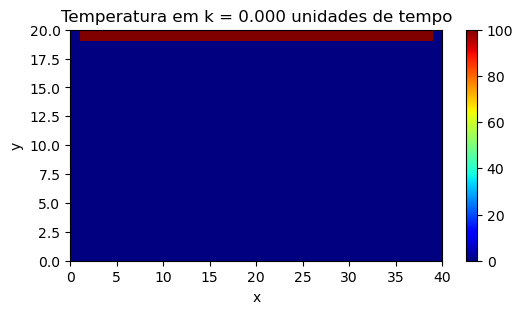

In [30]:
fig, ax = plt.subplots(figsize=(6, 3))

def animate(k):
    plotheatmap(u[k], k)

anim = animation.FuncAnimation(fig, 
                               animate, 
                               interval=10, 
                               frames=kmax, 
                               repeat=False)

# To save the animation using Pillow as a gif
writer = animation.PillowWriter(fps=15,
                                metadata=dict(artist='Me'),
                                bitrate=1800)
#anim.save('parabolica.gif', writer=writer)

Usamos o método explícito numericamente estável para

$$h_t< \frac{h^2}{4\alpha}$$

**Exemplo:**

Suponhamos uma placa quadrada fina com lado de 50 unidades de comprimento. A temperatura em todos os lugares dentro da placa é originalmente de 0 grau (em $t = 0$). Vamos considerar $h = 1$ e $\alpha = 2.0$. Agora podemos usar o código Python para resolver este problema numericamente para ver a temperatura em todos os lugares (indicada por $i$ e $j$ ) e ao longo do tempo (indicada por $k$). 

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.animation import FuncAnimation

In [24]:
xmax = 20
ymax = 40
kmax = 200

alpha = 2
h = 1
ht = (h ** 2)/(4 * alpha)
gamma = (alpha * ht) / (h ** 2)

# Cria o array para u(t,x,y)
u = np.empty((kmax, xmax, ymax))

# Condição inicial
u.fill(0)

# Condições de contorno
u[:,-1:,:] = 100.0  #top
u[:,:,:1] = 0             #left
u[:,:1,1:] = 0            #bottom
u[:,:,-1:] = 0      #right


Definimos as condições iniciais e de contorno, vamos escrever a função de cálculo com base no método de diferenças finitas que derivamos acima.

In [25]:
def calcula(u):
    for k in range(0, kmax-1, 1):
        for i in range(1, xmax -1, h):
            for j in range(1, ymax -1, h):
                u[k+1,i,j] = gamma*(u[k,i+1,j]+u[k,i-1,j]+u[k,i,j+1]+u[k,i,j-1]- 4*u[k,i,j]) + u[k,i,j]

    return u

In [26]:
u = calcula(u)

Vamos preparar a função plot para que possamos visualizar a solução (para cada k ) como um mapa de calor. Usamos a biblioteca Matplotlib , é fácil de usar.

In [27]:
def plotheatmap(u_k, k):
    plt.clf()  # clear figure
    plt.title(f"Temperatura em k = {k*ht:.3f} unidades de tempo")
    plt.xlabel("x")
    plt.ylabel("y")

    # This is to plot u_k (u at time-step k)
    plt.pcolormesh(u_k, cmap=plt.cm.jet, vmin=0, vmax=100)
    #plt.contourf(X,Y,u_k, cmap=plt.cm.jet)
    plt.colorbar()
    plt.show()
    #return plt


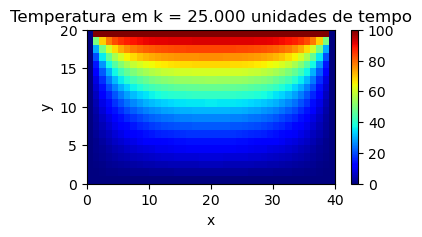

In [28]:
plotheatmap(u[-1], kmax)

Mais uma coisa que precisamos é animar o resultado porque queremos ver os pontos de temperatura dentro da placa mudarem ao longo do tempo. Então vamos criar a função para animar a solução.

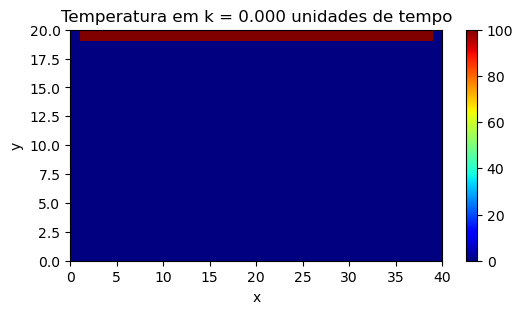

In [33]:
fig, ax = plt.subplots(figsize=(6, 3))

def animate(k):
    plotheatmap(u[k], k)

anim = animation.FuncAnimation(fig, 
                               animate, 
                               interval=10, 
                               frames=kmax, 
                               repeat=False)

# To save the animation using Pillow as a gif
writer = animation.PillowWriter(fps=15,
                                metadata=dict(artist='Me'),
                                bitrate=1800)
#anim.save('parabolica.gif', writer=writer)

### Referências

CHAPRA, Steven C.; CANALE, Raymond P. Métodos numéricos para engenharia. São Paulo: Grupo A, 2016. E-book. ISBN 9788580555691. Disponível em: https://integrada.minhabiblioteca.com.br/#/books/9788580555691/. Acesso em: 11 set. 2023.

NERVADOF, G. Solving 2D Heat Equation Numerically using Python. Level Up Coding, 2020. Disponível em: https://levelup.gitconnected.com/solving-2d-heat-equation-numerically-using-python-3334004aa01a. Acessado em: 12/08/2023

BUTLER,J. S. Numerical Methods for Differential Equations with
Python. Disponível em:
https://johnsbutler.netlify.app/files/Teaching/Numerical_Analysis_for_Differential_Equations.pdf. Acessado em: 12/08/2023


